In [1]:
from functionalcurves.depth import *
plt.rcParams['figure.figsize'] = (18, 9)

In [2]:
from functionalcurves.mixing_models import MixingLinearModel

# Depth point
X0 = np.array((1, -.2))

# Simulation parameters
N_samples, jump = 2_500, 50         
samples = range(jump, N_samples, jump)

Markov_chain = MixingLinearModel(mixing_rate = 1.1)

# A smaller error requires more samples to be generated
X = Markov_chain.simulate(n_samples = N_samples, error = .1 ** 4, innov_config = {'mean': [0,0], 'cov':[[2, 0],[0,.1]]}) 

n_samples required for error 0.00010000000000000002 :: 2506


100%|██████████| 2501/2501 [00:00<00:00, 65351.46it/s]


## Unconditional density.

Given that $X_n=\sum_{m=0}^\infty\frac{\xi_{n-m}}{(m+1)^p}$, taking $\mathbb{E}\xi_n=0$ yields
\begin{equation}
\mathbb{E}X_n^2=\sum_{n=0}^\infty\mathbb{E}\frac{\xi_n^2}{(n+1)^{2p}}+2\sum_{n=1}^\infty c_n(p)\mathbb{E}\xi_0\xi_n=\zeta(2p)\mathbb{E}\xi_0^2.
\end{equation}

In [3]:
mean, cov = Markov_chain.distribution()
print(f'Mean: {mean},\n cov: {cov}')

Mean: [0. 0.],
 cov: [[2.00198915 0.        ]
 [0.         0.10009946]]


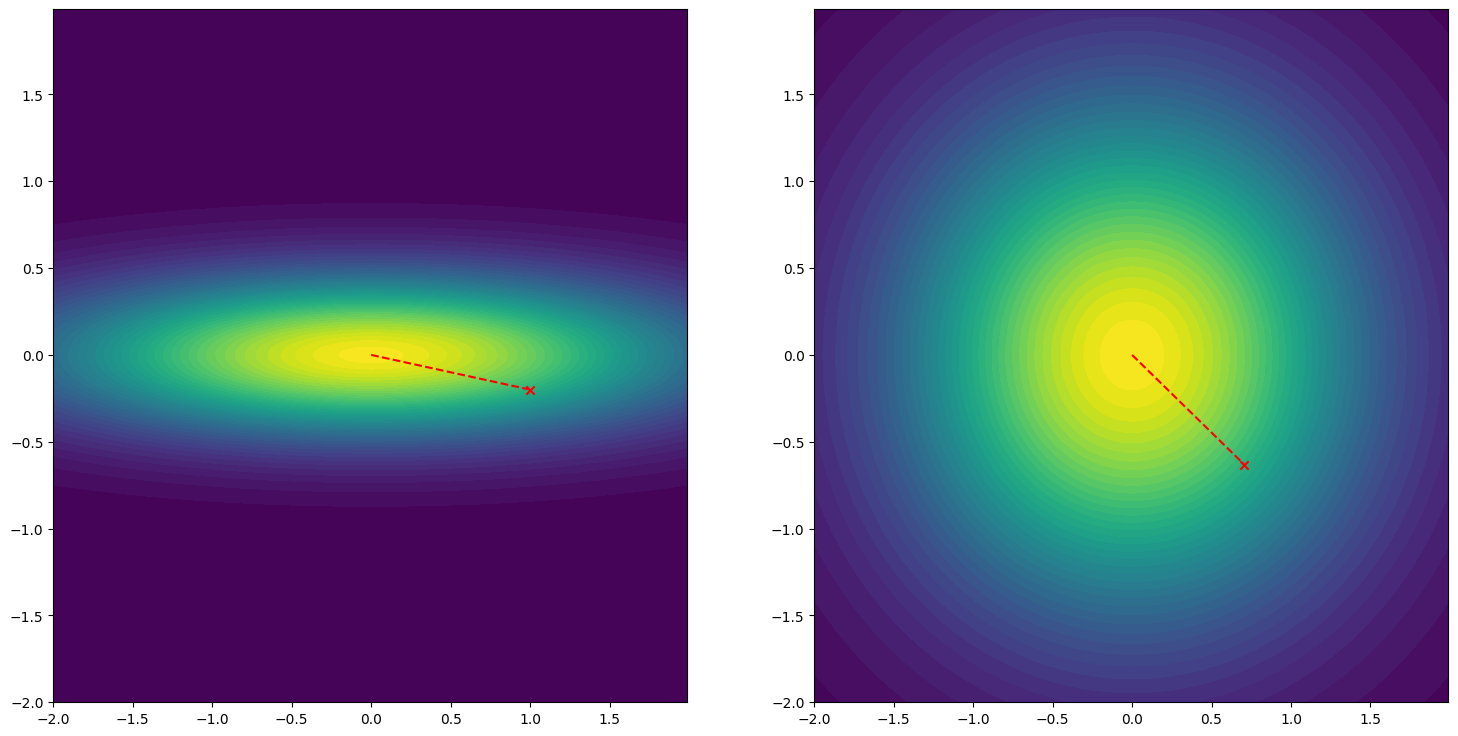

In [4]:
X0_translated = np.float64((X0 - mean) @ scipy.linalg.sqrtm(np.linalg.inv(cov)))

x, y = np.mgrid[-2:2:.01, -2:2:.01]
pos = np.dstack((x, y))
rv = scipy.stats.multivariate_normal(mean, cov)
fig2 = plt.figure()

ax1 = fig2.add_subplot(121)
ax1.contourf(x, y, rv.pdf(pos), levels = 50)
ax1.scatter(X0[0], X0[1], color = 'red', marker = 'x')
ax1.plot([mean[0], X0[0]], [mean[1], X0[1]], color = 'red', linestyle = 'dashed')

x, y = np.mgrid[-2:2:.01, -2:2:.01]
pos = np.dstack((x, y))
rv = scipy.stats.multivariate_normal([0,0], np.eye(2))
ax2 = fig2.add_subplot(122)
ax2.contourf(x, y, rv.pdf(pos), levels = 50)
ax2.scatter(X0_translated[0], X0_translated[1], color = 'red', marker = 'x')
ax2.plot([0, X0_translated[0]], [0, X0_translated[1]], color = 'red', linestyle = 'dashed')

x0 = np.arange(0, .5, .01)
y0 = 0 * np.array(x0)
# ax2.scatter(x0, y0, color = 'red', s = 1)
# ax2.scatter(y0, x0, color = 'blue', s = 1)

z1 = np.float64((np.matrix([x0,y0]).T @ scipy.linalg.sqrtm(cov)).T)
x1,y1 = z1[0], z1[1]
# ax1.scatter(np.asarray(x1)[0], np.asarray(y1)[0], color = 'red', s = 1)
# ax1.scatter(np.asarray(y1)[0], np.asarray(x1)[0], color = 'blue', s = 1)

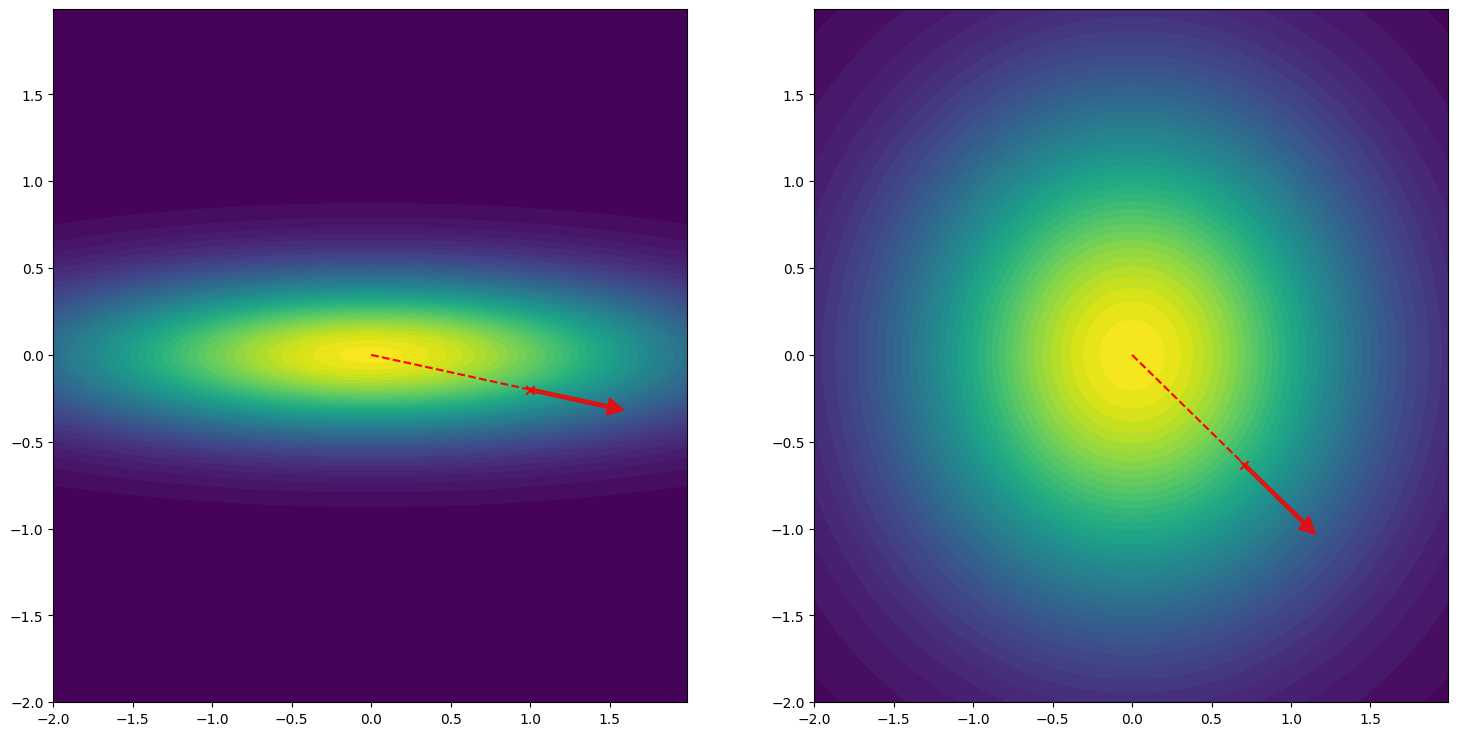

In [5]:
color_array = np.linalg.norm(X, axis = 1) ** .8
minimal_depth, minimal_angle, U0_norm = GaussianDepth(mean=mean, cov = cov, X0 = X0)
U1_norm = X0_translated / np.linalg.norm(X0_translated)

U0_norm = U0_norm / np.linalg.norm(U0_norm)

x, y = np.mgrid[-2:2:.01, -2:2:.01]
pos = np.dstack((x, y))
rv = scipy.stats.multivariate_normal(mean, cov)
fig2 = plt.figure()

ax1 = fig2.add_subplot(121)
ax1.contourf(x, y, rv.pdf(pos), levels = 50)
# ax1.scatter(X[:,0], X[:,1], c = color_array, cmap = 'Blues', alpha = .1)
ax1.scatter(X0[0], X0[1], color = 'red', marker = 'x')
ax1.plot([mean[0], X0[0]], [mean[1], X0[1]], color = 'red', linestyle = 'dashed')
ax1.arrow(X0[0], X0[1], U0_norm[0] / 2, U0_norm[1] / 2, head_width=0.1, head_length=0.1, width = 0.02, color = 'red', label = 'True', alpha = .8)

x, y = np.mgrid[-2:2:.01, -2:2:.01]
pos = np.dstack((x, y))
rv = scipy.stats.multivariate_normal([0,0], np.eye(2))
ax2 = fig2.add_subplot(122)
ax2.contourf(x, y, rv.pdf(pos), levels = 50)
ax2.scatter(X0_translated[0], X0_translated[1], color = 'red', marker = 'x')
ax2.plot([0, X0_translated[0]], [0, X0_translated[1]], color = 'red', linestyle = 'dashed')
ax2.arrow(X0_translated[0], X0_translated[1], U1_norm[0] / 2, U1_norm[1] / 2, head_width=0.1, head_length=0.1, width = 0.02, color = 'red', label = 'True', alpha = .8)

In [6]:
p = U0_norm / np.linalg.norm(U0_norm)

univariate_mean: float = p @ mean
univariate_var: float = (p @ cov @ p.T).item()
"""
H(x,u):={y:u'(y-x)>=0}. Let Y=u'X, then y~N(u'mu,u' Sigma u) and P(H(X,u))
"""
Y = scipy.stats.norm(loc = univariate_mean, scale = univariate_var ** .5)

minimal_depth = 1 - Y.cdf(p @ X0)

In [7]:
est_dir, est_dep, test = [], [], [] # Estimated lists
est_dir2, est_dep2, test = [], [], [] # Estimated lists

rel_depth1, rel_depth2 = [], []

for n in tqdm(samples):
    XN = X[:n]

    # Option degree to loop over the unit circle
    depth_estimator = Estimator(X = XN, X0 = X0, method = 'deg', num = n)

    # Option point_wise to loop over obervations projected on the unit circle
    depth_estimator2 = Estimator(X = XN, X0 = X0, method = 'point_wise')

    estimated_depth, estimated_direction, relative_angles, relative_depths, relative_directions = depth_estimator.main()
    estimated_depth2, estimated_direction2, relative_angles2, relative_depths2, relative_directions2 = depth_estimator2.main()

    rel_depth1.append(relative_depths)
    rel_depth2.append(relative_depths2)

    est_dir.append(estimated_direction)
    est_dep.append(estimated_depth)

    est_dir2.append(estimated_direction2)
    est_dep2.append(estimated_depth2)

100%|██████████| 49/49 [00:09<00:00,  5.38it/s]


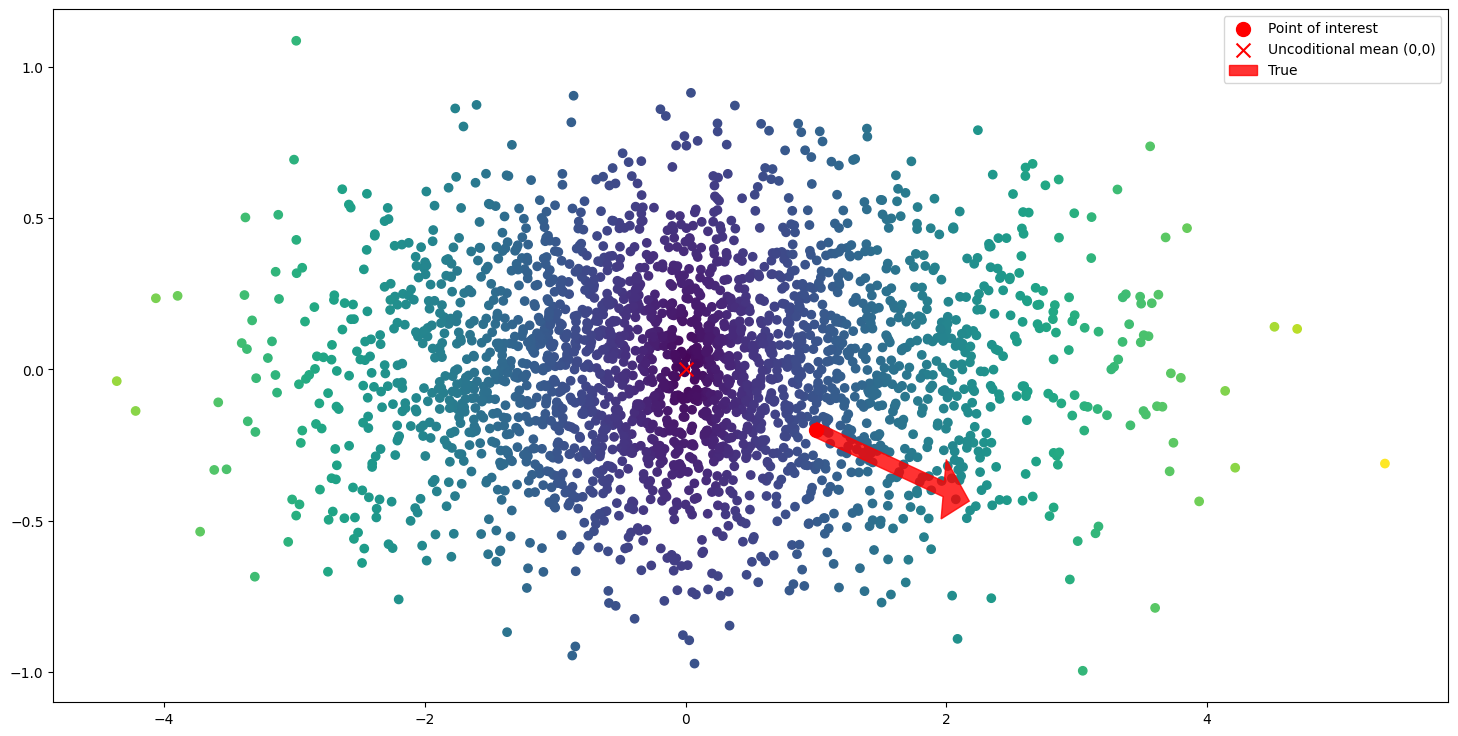

In [8]:
# We color each point based on its distance from (0,0)
color_array = np.linalg.norm(X, axis = 1) ** .8

plt.scatter(X[:,0], X[:,1], c = color_array)
plt.scatter(X0[0], X0[1], color = 'red', s = 100, label = 'Point of interest')
plt.scatter(mean[0], mean[1], color = 'red', s = 100, marker = 'x', label = 'Uncoditional mean (0,0)')
# plt.arrow(X0[0], X0[1], 7 * a.item(0), 7 * a.item(1), head_width=0.8, head_length=0.8, width = 0.2, color = 'red', label = 'True')
plt.arrow(X0[0], X0[1], U0_norm[0], U0_norm[1], head_width=0.2, head_length=0.2, width = 0.05, color = 'red', label = 'True', alpha = .8)
plt.legend()
plt.show()

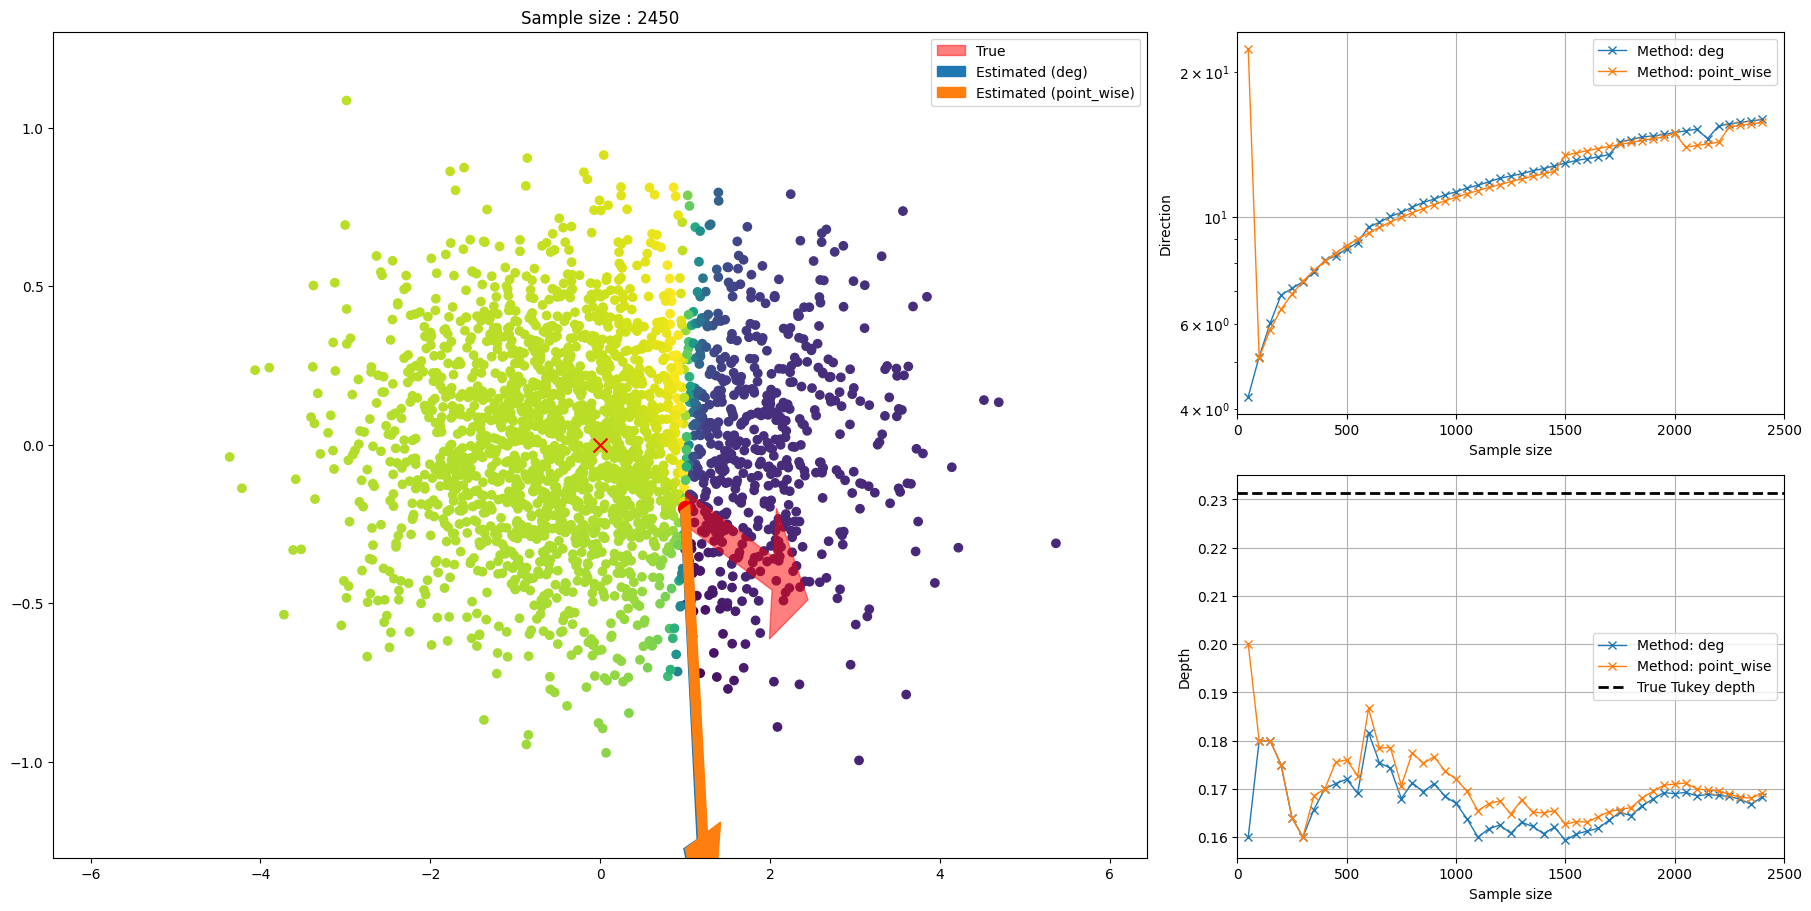

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import display, clear_output
from matplotlib.gridspec import GridSpec

diff1_main = np.abs(est_dir-minimal_angle)
diff2_main = np.abs(est_dir2-minimal_angle)

ub = max(np.abs(max(diff1_main)), np.abs(max(diff2_main)))
lb = min(min(diff1_main), min(diff2_main)) / 2

U0_norm_unit = U0_norm / np.linalg.norm(U0_norm)

scaling_factor = 1.5 * np.std(X[:,0]) 

for idx, n in enumerate(samples):
    XN = X[:n]

    X_shifted = XN - X0
    X_projected = X_shifted / np.linalg.norm(X_shifted, axis = 1).T[:, np.newaxis]

    estimated_minimal_vector = depth_estimator.Angle_to_vetor(est_dir[idx], normalise = True)
    estimated_minimal_vector2 = depth_estimator2.Angle_to_vetor(est_dir2[idx], normalise = True)

    estimated_minimal_vector = scaling_factor * estimated_minimal_vector / np.linalg.norm(estimated_minimal_vector)
    estimated_minimal_vector2 = scaling_factor * estimated_minimal_vector2 / np.linalg.norm(estimated_minimal_vector2)

    diff1 = est_dir[:idx]-minimal_angle
    diff2 = est_dir2[:idx]-minimal_angle

    # Clear the previous plot
    clear_output(wait=True)
    
    # Create a new figure and plot
    fig = plt.figure(layout="constrained")

    gs = GridSpec(2, 3, figure=fig)
    ax1 = fig.add_subplot(gs[0:, :2])
    # identical to ax1 = plt.subplot(gs.new_subplotspec((0, 0), colspan=3))
    ax2 = fig.add_subplot(gs[0,-1])
    ax3 = fig.add_subplot(gs[-1, -1])
    ax1.set_xlim(-1.2 * max(np.abs(X[:,0])), 1.2 * max(np.abs(X[:,0])))
    ax1.set_ylim(-1.2 * max(np.abs(X[:,1])), 1.2 * max(np.abs(X[:,1])))

    ax1.scatter(XN[:,0], XN[:,1], c = rel_depth2[idx])
    ax1.scatter(X0[0], X0[1], color = 'red', s = 100)
    ax1.scatter(mean[0], mean[1], color = 'red', s = 100, marker = 'x')
    ax1.arrow(X0[0], X0[1], scaling_factor * U0_norm_unit[0] / 2, scaling_factor * U0_norm_unit[1] / 2, head_width=0.2 * scaling_factor, head_length=0.2 * scaling_factor, width = 0.05 * scaling_factor, color = 'red', label = 'True', alpha = .5)
    ax1.arrow(X0[0], X0[1], estimated_minimal_vector.item(0) / 2, estimated_minimal_vector.item(1) / 2, head_width=0.2 * scaling_factor, head_length=0.2 * scaling_factor, width = 0.05 * scaling_factor, color = 'C0', label = "Estimated (deg)", alpha = 1)
    ax1.arrow(X0[0], X0[1], estimated_minimal_vector2.item(0) / 2, estimated_minimal_vector2.item(1) / 2, head_width=0.2 * scaling_factor, head_length=0.2 * scaling_factor, width = 0.05 * scaling_factor, color = 'C1', label = "Estimated (point_wise)", alpha = 1)
    ax1.legend()
    ax1.set_title(f'Sample size : {n}')

    ax2.set_xlim(0, N_samples)
    # ax[1].set_ylim(lb, ub)
    ax2.plot(samples[:idx], (np.array(samples[:idx]) ** (1/3)) *  np.abs(diff1), lw = 1, c = 'C0', marker = 'x', label = 'Method: deg')
    ax2.plot(samples[:idx], (np.array(samples[:idx]) ** (1/3)) *  np.abs(diff2), lw = 1, c = 'C1', marker = 'x', label = 'Method: point_wise')
    ax2.set_xlabel('Sample size')
    ax2.set_ylabel('Direction')
    ax2.grid(True)
    ax2.legend()
    ax2.set_yscale('log')

    ax3.set_xlim(0, N_samples)
    ax3.plot(samples[:idx], est_dep[:idx], lw = 1, c = 'C0', marker = 'x', label = 'Method: deg')
    ax3.plot(samples[:idx], est_dep2[:idx], lw = 1, c = 'C1', marker = 'x', label = 'Method: point_wise')
    ax3.axhline(minimal_depth, color = 'black', linestyle = 'dashed', linewidth = 2, label = 'True Tukey depth')
    ax3.set_xlabel('Sample size')
    ax3.set_ylabel('Depth')
    ax3.grid(True)
    ax3.legend()

    plt.show()

    # Pause for 0.5 seconds
    time.sleep(0.01)


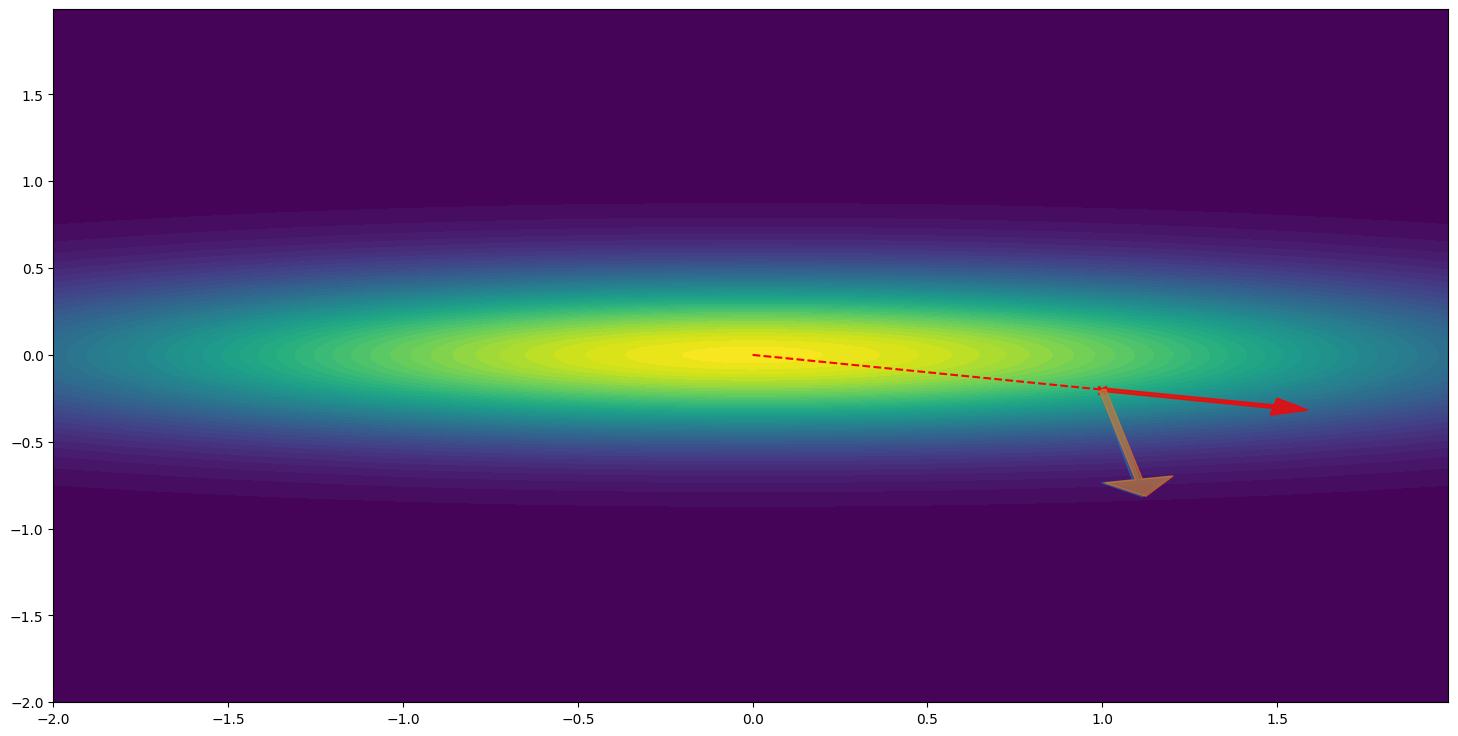

In [11]:
color_array = np.linalg.norm(X, axis = 1) ** .8
minimal_depth, minimal_angle, U0_norm = GaussianDepth(mean=mean, cov = cov, X0 = X0)
U1_norm = X0_translated / np.linalg.norm(X0_translated)

U0_norm = U0_norm / np.linalg.norm(U0_norm)

x, y = np.mgrid[-2:2:.01, -2:2:.01]
pos = np.dstack((x, y))
rv = scipy.stats.multivariate_normal(mean, cov)
fig2 = plt.figure()

ax1 = fig2.add_subplot(111)
ax1.contourf(x, y, rv.pdf(pos), levels = 50)
# ax1.scatter(X[:,0], X[:,1], c = color_array, cmap = 'Blues', alpha = .1)
ax1.scatter(X0[0], X0[1], color = 'red', marker = 'x')
ax1.plot([mean[0], X0[0]], [mean[1], X0[1]], color = 'red', linestyle = 'dashed')
ax1.arrow(X0[0], X0[1], U0_norm[0] / 2, U0_norm[1] / 2, head_width=0.1, head_length=0.1, width = 0.02, color = 'red', label = 'True', alpha = .8)
ax1.arrow(X0[0], X0[1], estimated_minimal_vector.item(0) / 4, estimated_minimal_vector.item(1) / 4, head_width=0.2, head_length=0.1, width = 0.02, color = 'C0', label = "Estimated (deg)", alpha = .5)
ax1.arrow(X0[0], X0[1], estimated_minimal_vector2.item(0) / 4, estimated_minimal_vector2.item(1) / 4, head_width=0.2, head_length=0.1, width = 0.02, color = 'C1', label = "Estimated (point_wise)", alpha = .5)

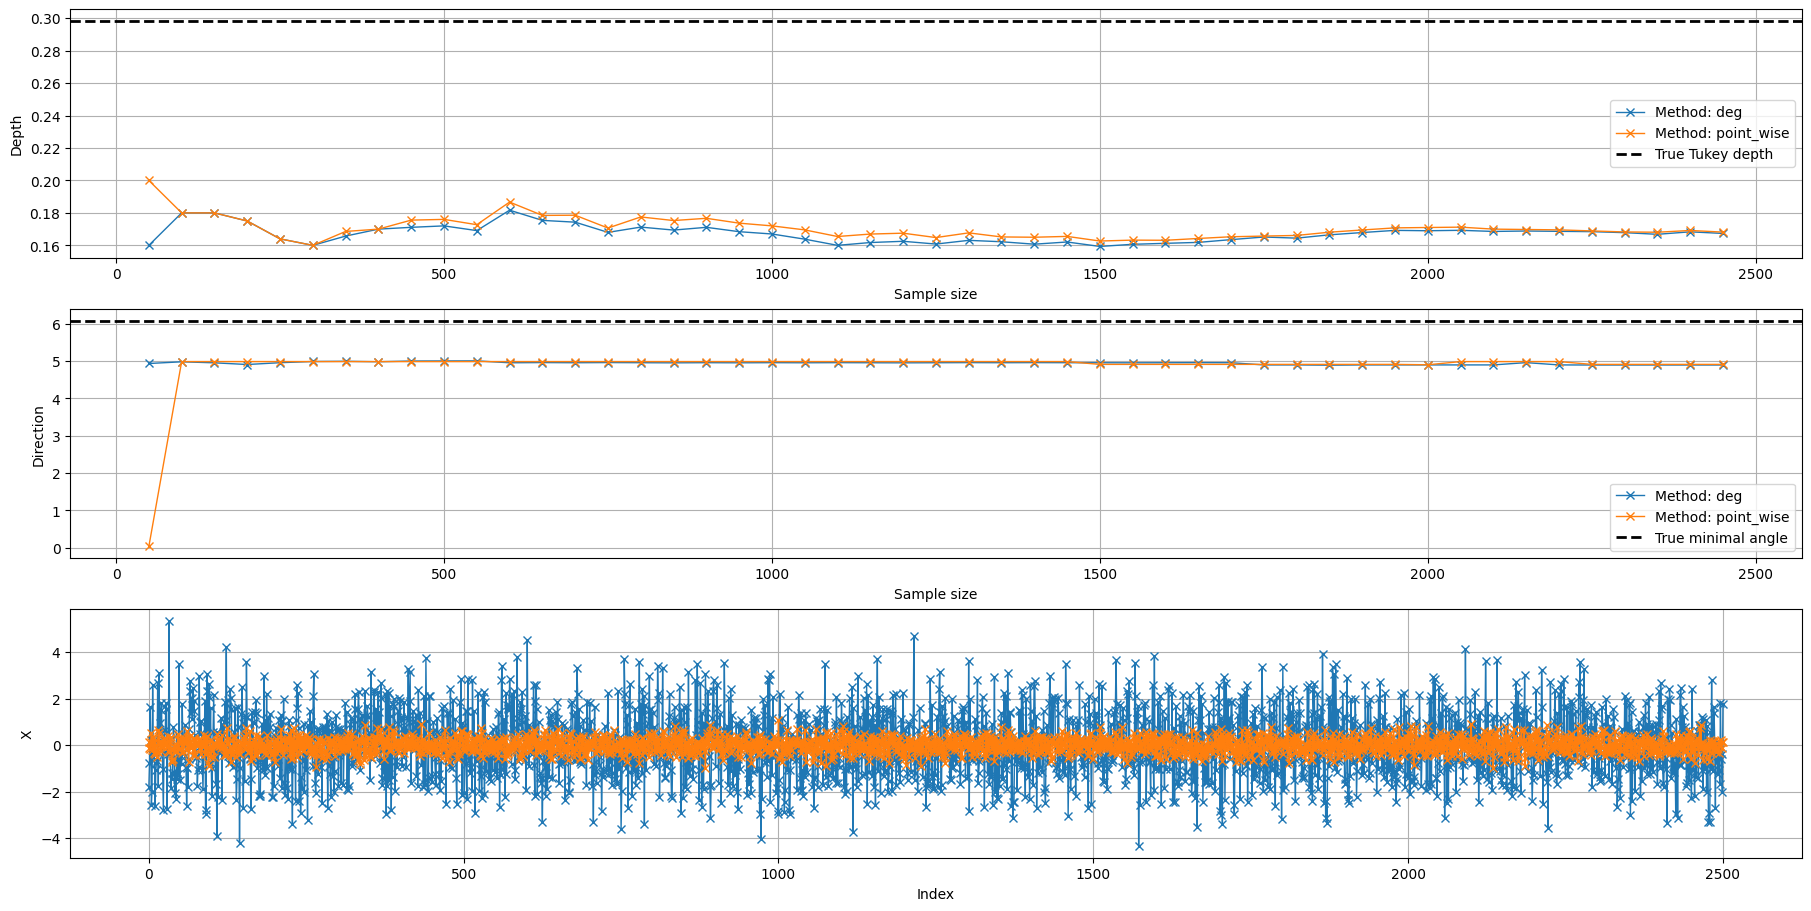

In [12]:
# Graph statistics
fig, axs = plt.subplots(3, 1, layout='constrained')
axs[0].plot(samples, est_dep, lw = 1, c = 'C0', marker = 'x', label = 'Method: deg')
axs[0].plot(samples, est_dep2, lw = 1, c = 'C1', marker = 'x', label = 'Method: point_wise')
axs[0].axhline(minimal_depth, color = 'black', linestyle = 'dashed', linewidth = 2, label = 'True Tukey depth')
axs[0].set_xlabel('Sample size')
axs[0].set_ylabel('Depth')
axs[0].grid(True)
axs[0].legend()

axs[1].plot(samples, est_dir, lw = 1, c = 'C0', marker = 'x', label = 'Method: deg')
axs[1].plot(samples, est_dir2, lw = 1, c = 'C1', marker = 'x', label = 'Method: point_wise')
axs[1].axhline(minimal_angle, color = 'black', linestyle = 'dashed', linewidth = 2, label = 'True minimal angle')
axs[1].set_xlabel('Sample size')
axs[1].set_ylabel('Direction')
axs[1].grid(True)
axs[1].legend()
# axs[1].set_ylim([true_TP - np.pi / 8, true_TP + np.pi / 8])

axs[2].plot(X[:,0], lw = 1, c = 'C0', marker = 'x')
axs[2].plot(X[:,1], lw = 1, c = 'C1', marker = 'x')
axs[2].set_xlabel('Index')
axs[2].set_ylabel('X')
axs[2].grid(True)

plt.show()